In [1]:
!pip install timm pyswarms shap xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.1 MB/s eta 0:00:00


In [2]:
import os

# Check what's inside your uploaded dataset
base = "/kaggle/input/all-leukemia-dataset"

for root, dirs, files in os.walk(base):
    level = root.replace(base, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level >= 3:   # limit depth for readability
        break

In [3]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

import timm                                      # Vision Transformer
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              mean_squared_error, mean_absolute_error, r2_score)
from pyswarms.single.global_best import GlobalBestPSO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
import os
print(os.listdir("/kaggle/input/datasets/deetchanad21mis1061"))

['all-leukemia-dataset']


In [5]:
import os
base = "/kaggle/input/datasets/deetchanad21mis1061"

for item in os.listdir(base):
    full = os.path.join(base, item)
    print(f"📁 {item}/")
    if os.path.isdir(full):
        for sub in os.listdir(full):
            subpath = os.path.join(full, sub)
            if os.path.isdir(subpath):
                for sub2 in os.listdir(subpath):
                    sub2path = os.path.join(subpath, sub2)
                    if os.path.isdir(sub2path):
                        imgs = [f for f in os.listdir(sub2path)
                                if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]
                        print(f"    📁 {sub}/{sub2}/  → {len(imgs)} images")
                    else:
                        print(f"  📄 {sub}/{sub2}")
            else:
                print(f"  📄 {sub}")

📁 all-leukemia-dataset/
    📁 ALL_IDB/ALL_IDB/  → 0 images
    📁 C-NMC_Leukemia/fold_0/  → 0 images
    📁 C-NMC_Leukemia/fold_1/  → 0 images
    📁 C-NMC_Leukemia/fold_2/  → 0 images


In [6]:
import os
base = "/kaggle/input/datasets/deetchanad21mis1061/all-leukemia-dataset"

for root, dirs, files in os.walk(base):
    imgs = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]
    if imgs:
        rel = root.replace(base, '')
        print(f"📁 {rel}/  → {len(imgs)} images  (e.g. {imgs[0]})")

📁 /ALL_IDB/ALL_IDB/Leukemia/L3/  → 38 images  (e.g. Im003_35.jpg)
📁 /ALL_IDB/ALL_IDB/Leukemia/L2/  → 50 images  (e.g. Im025_1.jpg)
📁 /ALL_IDB/ALL_IDB/Leukemia/L1/  → 50 images  (e.g. Im107_0.jpg)
📁 /ALL_IDB/ALL_IDB/Normal/hem/  → 1130 images  (e.g. UID_H12_18_4_hem.bmp)
📁 /C-NMC_Leukemia/fold_0/fold_0/all/  → 2397 images  (e.g. UID_28_5_3_all.bmp)
📁 /C-NMC_Leukemia/fold_0/fold_0/hem/  → 1130 images  (e.g. UID_H12_18_4_hem.bmp)
📁 /C-NMC_Leukemia/fold_1/fold_1/all/  → 2418 images  (e.g. UID_46_17_8_all.bmp)
📁 /C-NMC_Leukemia/fold_1/fold_1/hem/  → 1163 images  (e.g. UID_H14_7_7_hem.bmp)
📁 /C-NMC_Leukemia/fold_2/fold_2/all/  → 2457 images  (e.g. UID_47_7_3_all.bmp)
📁 /C-NMC_Leukemia/fold_2/fold_2/hem/  → 1096 images  (e.g. UID_H23_5_5_hem.bmp)


In [7]:
import os

base = "/kaggle/input/datasets/deetchanad21mis1061/all-leukemia-dataset"

# ── ALL_IDB ───────────────────────────────────────────────────────────────────
# Leukemia folders: L1, L2, L3 → label 1
# Normal folder:    Normal/hem  → label 0
# NOTE: ALL_IDB filenames ending in _1 = leukemia, _0 = normal
#       But since they're already in separate folders, we use folder labels directly

ALLIDB_LEUK_L1  = f"{base}/ALL_IDB/ALL_IDB/Leukemia/L1"
ALLIDB_LEUK_L2  = f"{base}/ALL_IDB/ALL_IDB/Leukemia/L2"
ALLIDB_LEUK_L3  = f"{base}/ALL_IDB/ALL_IDB/Leukemia/L3"
ALLIDB_NORMAL   = f"{base}/ALL_IDB/ALL_IDB/Normal/hem"

# ── C-NMC (all 3 folds) ───────────────────────────────────────────────────────
# all/ → leukemia (label 1)
# hem/ → normal   (label 0)

CNMC_FOLD0_ALL  = f"{base}/C-NMC_Leukemia/fold_0/fold_0/all"
CNMC_FOLD0_HEM  = f"{base}/C-NMC_Leukemia/fold_0/fold_0/hem"
CNMC_FOLD1_ALL  = f"{base}/C-NMC_Leukemia/fold_1/fold_1/all"
CNMC_FOLD1_HEM  = f"{base}/C-NMC_Leukemia/fold_1/fold_1/hem"
CNMC_FOLD2_ALL  = f"{base}/C-NMC_Leukemia/fold_2/fold_2/all"
CNMC_FOLD2_HEM  = f"{base}/C-NMC_Leukemia/fold_2/fold_2/hem"

# ── Load all images ───────────────────────────────────────────────────────────
def load_images_from_folder(folder, label):
    paths, labels = [], []
    if not os.path.exists(folder):
        print(f"⚠️  Not found: {folder}")
        return paths, labels
    for fname in os.listdir(folder):
        if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            paths.append(os.path.join(folder, fname))
            labels.append(label)
    return paths, labels

all_paths, all_labels = [], []

folder_map = [
    (ALLIDB_LEUK_L1, 1, "ALL_IDB L1 (Leukemia)"),
    (ALLIDB_LEUK_L2, 1, "ALL_IDB L2 (Leukemia)"),
    (ALLIDB_LEUK_L3, 1, "ALL_IDB L3 (Leukemia)"),
    (ALLIDB_NORMAL,  0, "ALL_IDB Normal (hem)  "),
    (CNMC_FOLD0_ALL, 1, "C-NMC fold_0 all      "),
    (CNMC_FOLD0_HEM, 0, "C-NMC fold_0 hem      "),
    (CNMC_FOLD1_ALL, 1, "C-NMC fold_1 all      "),
    (CNMC_FOLD1_HEM, 0, "C-NMC fold_1 hem      "),
    (CNMC_FOLD2_ALL, 1, "C-NMC fold_2 all      "),
    (CNMC_FOLD2_HEM, 0, "C-NMC fold_2 hem      "),
]

for folder, label, name in folder_map:
    p, l = load_images_from_folder(folder, label)
    all_paths  += p
    all_labels += l
    print(f"  {'✅' if len(p)>0 else '❌'}  {name}  →  {len(p)} images")

print(f"\n{'─'*45}")
print(f"  Total images  : {len(all_paths)}")
print(f"  Normal   (0)  : {all_labels.count(0)}")
print(f"  Leukemia (1)  : {all_labels.count(1)}")

  ✅  ALL_IDB L1 (Leukemia)  →  50 images
  ✅  ALL_IDB L2 (Leukemia)  →  50 images
  ✅  ALL_IDB L3 (Leukemia)  →  38 images
  ✅  ALL_IDB Normal (hem)    →  1130 images
  ✅  C-NMC fold_0 all        →  2397 images
  ✅  C-NMC fold_0 hem        →  1130 images
  ✅  C-NMC fold_1 all        →  2418 images
  ✅  C-NMC fold_1 hem        →  1163 images
  ✅  C-NMC fold_2 all        →  2457 images
  ✅  C-NMC fold_2 hem        →  1096 images

─────────────────────────────────────────────
  Total images  : 11929
  Normal   (0)  : 4519
  Leukemia (1)  : 7410


In [8]:
X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    all_paths, all_labels,
    test_size=0.2,
    stratify=all_labels,
    random_state=42
)

print(f"Train: {len(X_train_paths)}  |  Test: {len(X_test_paths)}")

Train: 9543  |  Test: 2386


In [9]:
import pandas as pd

# Save test image paths and true labels with fixed seed
test_df = pd.DataFrame({
    'path':  X_test_paths,
    'label': y_test
})
test_df.to_csv('/kaggle/working/common_test_set.csv', index=False)
print(f"✅ Common test set saved: {len(test_df)} images")
print(test_df.head())

✅ Common test set saved: 2386 images
                                                path  label
0  /kaggle/input/datasets/deetchanad21mis1061/all...      0
1  /kaggle/input/datasets/deetchanad21mis1061/all...      1
2  /kaggle/input/datasets/deetchanad21mis1061/all...      1
3  /kaggle/input/datasets/deetchanad21mis1061/all...      1
4  /kaggle/input/datasets/deetchanad21mis1061/all...      1


In [10]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

class LeukemiaDataset(Dataset):
    def __init__(self, paths, labels, transform):
        self.paths     = paths
        self.labels    = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), self.labels[idx]

train_loader = DataLoader(
    LeukemiaDataset(X_train_paths, y_train, transform),
    batch_size=32, shuffle=False, num_workers=2
)
test_loader = DataLoader(
    LeukemiaDataset(X_test_paths, y_test, transform),
    batch_size=32, shuffle=False, num_workers=2
)

print("DataLoaders ready ✅")

DataLoaders ready ✅


In [32]:
# ── Fine-tune ResNet50 on leukemia data ───────────────────────────────────────
import torch.nn as nn
import torch.optim as optim
from torchvision import models

print("Fine-tuning ResNet50...")

# Build trainable ResNet50
ft_resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Unfreeze last 2 layers only
for name, param in ft_resnet.named_parameters():
    param.requires_grad = False
for name, param in ft_resnet.layer4.named_parameters():
    param.requires_grad = True     # unfreeze layer4

# Replace final FC with leukemia classifier
ft_resnet.fc = nn.Sequential(
    nn.Linear(2048, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 2)
)
ft_resnet = ft_resnet.to(device)

# Train
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, ft_resnet.parameters()),
    lr=1e-4
)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

best_acc_ft = 0
for epoch in range(8):
    ft_resnet.train()
    correct = total = 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/8"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = ft_resnet(imgs)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()
        correct += (out.argmax(1) == labels).sum().item()
        total   += labels.size(0)
    scheduler.step()

    # Val accuracy
    ft_resnet.eval()
    vc = vt = 0
    with torch.no_grad():
        for imgs, labels in test_loader:
            out = ft_resnet(imgs.to(device))
            vc += (out.argmax(1) == labels.to(device)).sum().item()
            vt += labels.size(0)
    val_acc = vc/vt
    print(f"Epoch {epoch+1} | Train: {correct/total*100:.2f}% | Test: {val_acc*100:.2f}%")
    if val_acc > best_acc_ft:
        best_acc_ft = val_acc
        torch.save(ft_resnet.state_dict(), '/kaggle/working/best_ft_resnet.pth')

ft_resnet.load_state_dict(torch.load('/kaggle/working/best_ft_resnet.pth'))
ft_resnet.eval()
print(f"\n✅ Fine-tuned ResNet50 best accuracy: {best_acc_ft*100:.2f}%")

Fine-tuning ResNet50...


Epoch 1/8: 100%|██████████| 299/299 [00:50<00:00,  5.97it/s]


Epoch 1 | Train: 85.21% | Test: 86.71%


Epoch 2/8: 100%|██████████| 299/299 [00:47<00:00,  6.35it/s]


Epoch 2 | Train: 94.21% | Test: 86.55%


...

Epoch 6 | Train: 99.99% | Test: 93.50%


Epoch 7/8: 100%|██████████| 299/299 [00:48<00:00,  6.21it/s]


Epoch 7 | Train: 100.00% | Test: 93.67%


Epoch 8/8: 100%|██████████| 299/299 [00:48<00:00,  6.20it/s]


Epoch 8 | Train: 100.00% | Test: 93.67%

✅ Fine-tuned ResNet50 best accuracy: 93.67%


In [33]:
# Remove FC layer to use as feature extractor
ft_resnet_feat      = models.resnet50(weights=None)
ft_resnet_feat.fc   = nn.Identity()
ft_resnet_feat      = ft_resnet_feat.to(device)

# Load fine-tuned weights except FC
state = torch.load('/kaggle/working/best_ft_resnet.pth')
state = {k: v for k, v in state.items() if 'fc' not in k}
ft_resnet_feat.load_state_dict(state, strict=False)
ft_resnet_feat.eval()

def extract_features(loader, desc="Extracting"):
    feats, lbls = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=desc):
            imgs    = imgs.to(device)
            r_feat  = ft_resnet_feat(imgs)              # fine-tuned (B, 2048)
            v_feat  = vit(imgs)                         # original ViT  (B, 768)
            fused   = torch.cat([r_feat, v_feat], dim=1)  # (B, 2816)
            feats.append(fused.cpu().numpy())
            lbls.append(labels.numpy())
    return np.vstack(feats), np.concatenate(lbls)

print("⏳ Extracting fine-tuned features...")
X_train_feat, y_train_np = extract_features(train_loader, "Train")
X_test_feat,  y_test_np  = extract_features(test_loader,  "Test")
print(f"Train: {X_train_feat.shape} | Test: {X_test_feat.shape}")

⏳ Extracting fine-tuned features...


Test: 100%|██████████| 75/75 [00:38<00:00,  1.97it/s]

Train: (9543, 2816) | Test: (2386, 2816)


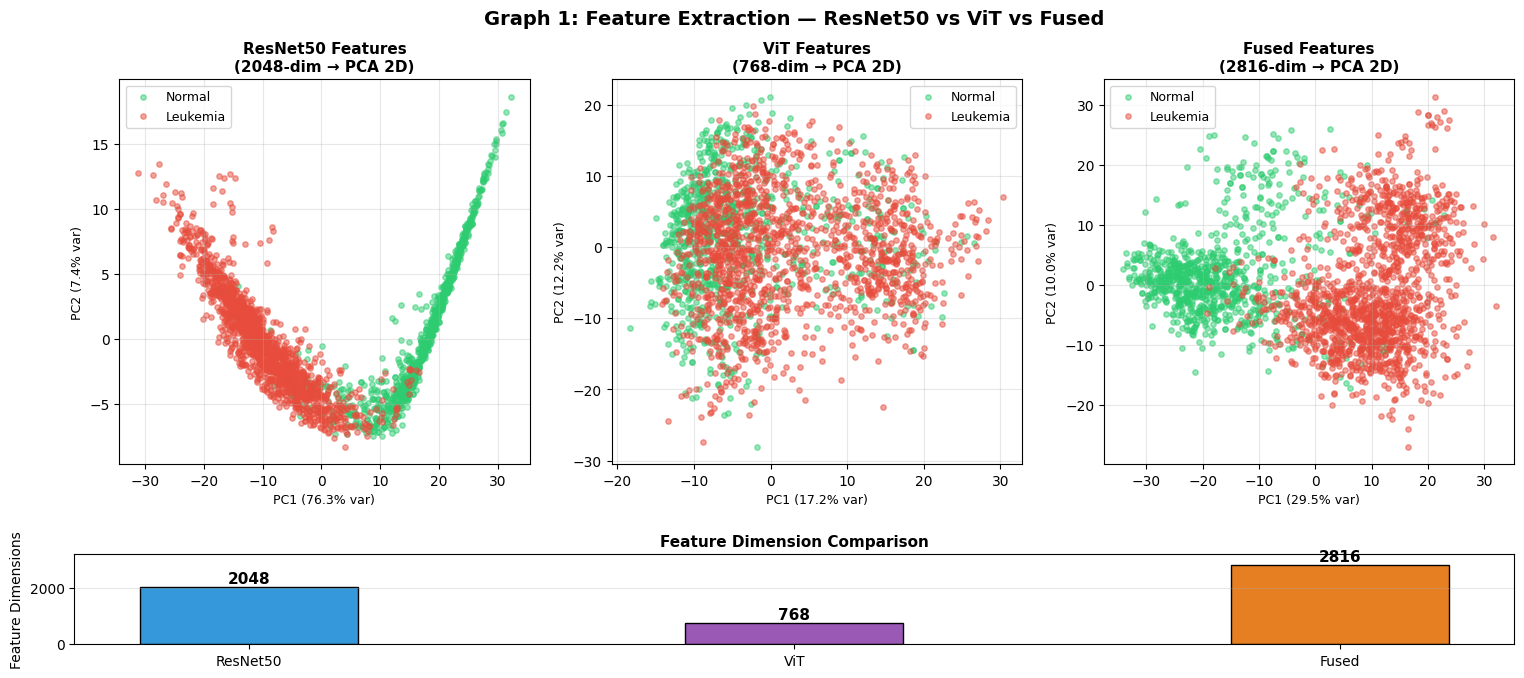

Graph 1 saved ✅


In [34]:
# ── Graph 1: ResNet50 vs ViT vs Fused Feature Distribution ───────────────────
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Graph 1: Feature Extraction — ResNet50 vs ViT vs Fused",
             fontsize=14, fontweight='bold', y=1.02)

colors = ['#2ecc71' if l == 0 else '#e74c3c' for l in y_test_np]

# Split fused features back into ResNet and ViT parts
X_resnet = X_test_feat[:, :2048]     # first 2048 = ResNet50
X_vit    = X_test_feat[:, 2048:]     # last  768  = ViT
X_fused  = X_test_feat               # all 2816

for ax, X, title in zip(axes,
                         [X_resnet, X_vit, X_fused],
                         ["ResNet50 Features\n(2048-dim → PCA 2D)",
                          "ViT Features\n(768-dim → PCA 2D)",
                          "Fused Features\n(2816-dim → PCA 2D)"]):
    pca   = PCA(n_components=2, random_state=42)
    X_2d  = pca.fit_transform(X)
    var   = pca.explained_variance_ratio_

    ax.scatter(X_2d[y_test_np==0, 0], X_2d[y_test_np==0, 1],
               c='#2ecc71', alpha=0.5, s=15, label='Normal')
    ax.scatter(X_2d[y_test_np==1, 0], X_2d[y_test_np==1, 1],
               c='#e74c3c', alpha=0.5, s=15, label='Leukemia')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(f"PC1 ({var[0]*100:.1f}% var)", fontsize=9)
    ax.set_ylabel(f"PC2 ({var[1]*100:.1f}% var)", fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Bar chart of feature dimensions
ax_bar = fig.add_axes([0.1, -0.25, 0.8, 0.18])
models_names = ['ResNet50', 'ViT', 'Fused']
dims         = [2048, 768, 2816]
bar_colors   = ['#3498db', '#9b59b6', '#e67e22']
bars = ax_bar.bar(models_names, dims, color=bar_colors, width=0.4, edgecolor='black')
for bar, d in zip(bars, dims):
    ax_bar.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                str(d), ha='center', va='bottom', fontweight='bold', fontsize=11)
ax_bar.set_ylabel("Feature Dimensions", fontsize=10)
ax_bar.set_title("Feature Dimension Comparison", fontsize=11, fontweight='bold')
ax_bar.set_ylim(0, 3200)
ax_bar.grid(axis='y', alpha=0.3)

plt.savefig("graph1_feature_extraction.png", dpi=150, bbox_inches='tight')
plt.show()
print("Graph 1 saved ✅")

In [35]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

# ── Global list to store convergence history ──────────────────────────────────
hho_convergence = []   # ← ADDED: tracks best fitness each iteration

def hho_feature_selection(X, y, n_hawks=10, max_iter=25):
    """
    Binary Harris Hawks Optimization for feature selection.
    Minimizes: (1 - KNN accuracy) + 0.01 * (selected features ratio)
    """
    from sklearn.neighbors import KNeighborsClassifier

    global hho_convergence           # ← ADDED
    hho_convergence = []             # ← ADDED: reset before each run

    n_feat    = X.shape[1]
    positions = np.random.uniform(0, 1, (n_hawks, n_feat))

    def fitness(pos):
        mask = (sigmoid(pos) > 0.5)
        if mask.sum() == 0:
            return 1.0
        if mask.sum() < 100:
            return 1.0
        
        clf = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
        clf.fit(X[:, mask], y)
        acc   = clf.score(X[:, mask], y)
        ratio = mask.sum() / n_feat
        return (1 - acc) + 0.01 * ratio    # lower = better

    # Evaluate initial population
    fit_scores = np.array([fitness(p) for p in positions])
    rabbit_idx = np.argmin(fit_scores)
    rabbit_pos = positions[rabbit_idx].copy()
    rabbit_fit = fit_scores[rabbit_idx]

    print(f"{'Iter':>5}  {'BestFit':>10}  {'SelFeatures':>12}")
    print("-" * 35)

    for t in range(max_iter):
        E0 = 2 * np.random.rand() - 1
        E  = 2 * E0 * (1 - t / max_iter)

        for i in range(n_hawks):
            r = np.random.rand()
            if abs(E) >= 1:                            # Exploration
                rand_idx      = np.random.randint(n_hawks)
                positions[i]  = (positions[rand_idx]
                                 - r * abs(positions[rand_idx]
                                           - 2 * r * positions[i]))
            else:                                      # Exploitation
                positions[i]  = (rabbit_pos
                                 - E * abs(rabbit_pos - positions[i]))
            positions[i] = np.clip(positions[i], 0, 1)

        fit_scores = np.array([fitness(p) for p in positions])
        best_idx   = np.argmin(fit_scores)
        if fit_scores[best_idx] < rabbit_fit:
            rabbit_fit = fit_scores[best_idx]
            rabbit_pos = positions[best_idx].copy()

        hho_convergence.append(rabbit_fit)   # ← ADDED: save best fitness

        n_sel = (sigmoid(rabbit_pos) > 0.5).sum()
        if (t + 1) % 5 == 0:
            print(f"{t+1:>5}  {rabbit_fit:>10.4f}  {n_sel:>12}")

    selected = np.where(sigmoid(rabbit_pos) > 0.5)[0]
    if len(selected) < 10:                             # safety fallback
        selected = np.argsort(rabbit_pos)[-300:]

    print(f"\nHHO selected {len(selected)} features ✅")
    return selected


# ── Run HHO ───────────────────────────────────────────────────────────────────
# REPLACE the idx_sub and hho run lines with this:
idx_sub      = np.random.choice(len(X_train_feat),
                                min(1500, len(X_train_feat)),
                                replace=False)
X_sub, y_sub = X_train_feat[idx_sub], y_train_np[idx_sub]

print("🦅 Running HHO Feature Selection...")
hho_idx      = hho_feature_selection(X_sub, y_sub, n_hawks=15, max_iter=40)

X_train_hho  = X_train_feat[:, hho_idx]
X_test_hho   = X_test_feat[:,  hho_idx]

print(f"Shape after HHO: {X_train_hho.shape}")

🦅 Running HHO Feature Selection...
 Iter     BestFit   SelFeatures
-----------------------------------
    5      0.0075           240
   10      0.0062           255
   15      0.0062           255
   20      0.0062           255
   25      0.0062           255
   30      0.0062           255
   35      0.0062           255
   40      0.0062           255

HHO selected 255 features ✅
Shape after HHO: (9543, 255)


In [37]:
def pso_fitness_fn(particles):
    from sklearn.neighbors import KNeighborsClassifier
    costs = []
    n_feat = particles.shape[1]
    for p in particles:
        mask = sigmoid(p) > 0.5
        if mask.sum() < 50:        # ← minimum 50 features after PSO
            costs.append(1.0)
            continue
        clf = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
        clf.fit(X_sub_hho[:, mask], y_sub)
        acc   = clf.score(X_sub_hho[:, mask], y_sub)
        ratio = mask.sum() / n_feat
        costs.append((1 - acc) + 0.005 * ratio)  # ← reduced penalty from 0.01 to 0.005
    return np.array(costs)

X_sub_hho = X_train_hho[idx_sub]

n_feat_hho = X_train_hho.shape[1]
options    = {'c1': 2.0, 'c2': 2.0, 'w': 0.6}
optimizer  = GlobalBestPSO(
    n_particles = 15,
    dimensions  = n_feat_hho,
    options     = options
)

print("🌀 Running PSO Feature Selection...")
best_cost, best_pos = optimizer.optimize(pso_fitness_fn, iters=50, verbose=True)

pso_mask = sigmoid(best_pos) > 0.5
pso_idx  = np.where(pso_mask)[0]
if len(pso_idx) < 80:              # ← safety net minimum
    pso_idx = np.argsort(np.abs(best_pos))[-200:]

X_train_final = X_train_hho[:, pso_idx]
X_test_final  = X_test_hho[:,  pso_idx]

print(f"\nPSO selected {len(pso_idx)} features ✅")
print(f"Final feature shape: {X_train_final.shape}")

2026-03-17 21:26:23,323 - pyswarms.single.global_best - INFO - Optimize for 50 iters with {'c1': 2.0, 'c2': 2.0, 'w': 0.6}


🌀 Running PSO Feature Selection...


pyswarms.single.global_best: 100%|██████████|50/50, best_cost=0.00467
2026-03-17 21:26:38,893 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.004666666666666668, best pos: [ 6.30366137e-01  1.59711467e+00  2.20166831e-01  2.33802116e+00
 -1.69158086e+01  3.07660786e+00 -6.39559546e+00 -3.01949092e+00
 -5.88892516e-04  6.81540236e+00  8.82026390e-02 -1.07031403e+00
 -1.05254993e+01  9.36667187e-01  1.50533257e+00  7.19186389e+00
  8.58559257e-01  8.28629645e-01  1.44957923e+00 -3.02164226e-01
 -1.92141607e+00 -4.69853053e-02 -2.57114795e+00  3.24239731e+00
  1.07056297e+01  6.73684648e+00  5.81889571e-01  1.35715254e+00
  3.54858992e+00  3.44932677e-01  3.07037102e+00 -6.43225313e-01
  9.84505011e-01  7.77273393e-01  3.41481781e-01 -2.01748255e+00
 -3.63513790e+01 -5.20514261e-01 -1.04141627e+01  5.81544680e+00
 -9.09819611e-01 -5.42385899e+00  2.38182635e+00 -2.53403748e+00
 -8.85390477e-01  5.45691540e-01  1.77508126e+00  6.19614279e+00
  2.43764180e-01 -1.


PSO selected 136 features ✅
Final feature shape: (9543, 136)


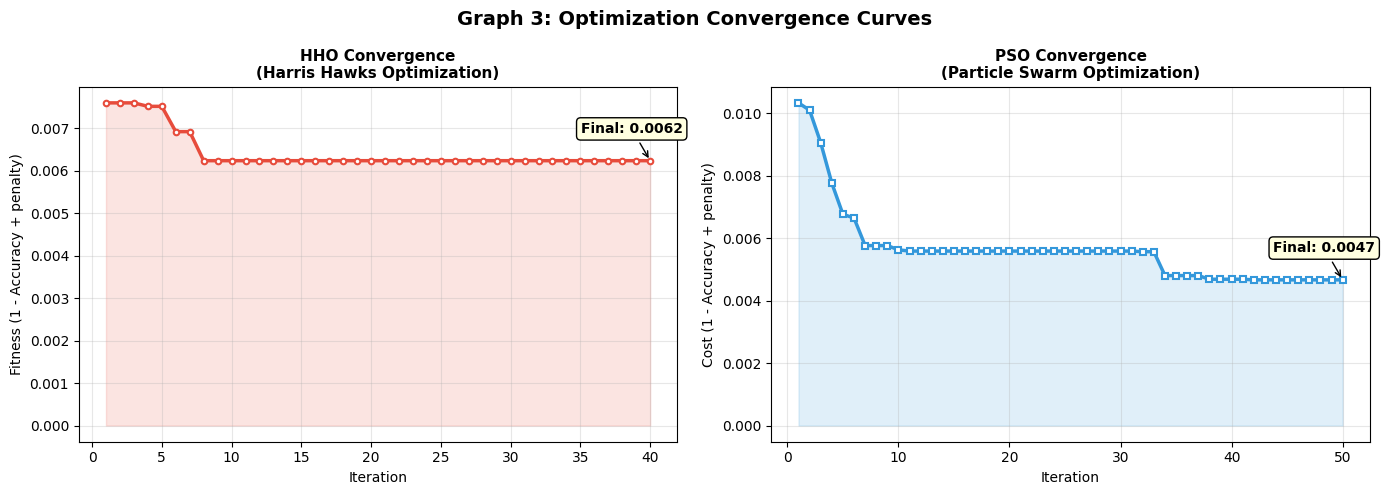

Graph 3 saved ✅


In [38]:
# ── Graph 3: Convergence Curves — HHO & PSO ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Graph 3: Optimization Convergence Curves",
             fontsize=14, fontweight='bold')

# ── HHO Convergence ───────────────────────────────────────────────────────────
axes[0].plot(range(1, len(hho_convergence)+1), hho_convergence,
             color='#e74c3c', linewidth=2.5, marker='o',
             markersize=4, markerfacecolor='white', markeredgewidth=1.5)
axes[0].fill_between(range(1, len(hho_convergence)+1), hho_convergence,
                     alpha=0.15, color='#e74c3c')
axes[0].set_title("HHO Convergence\n(Harris Hawks Optimization)",
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel("Iteration", fontsize=10)
axes[0].set_ylabel("Fitness (1 - Accuracy + penalty)", fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].annotate(f"Final: {hho_convergence[-1]:.4f}",
                 xy=(len(hho_convergence), hho_convergence[-1]),
                 xytext=(-50, 20), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round', fc='lightyellow'))

# ── PSO Convergence ───────────────────────────────────────────────────────────
pso_convergence = optimizer.cost_history   # pyswarms stores this automatically

axes[1].plot(range(1, len(pso_convergence)+1), pso_convergence,
             color='#3498db', linewidth=2.5, marker='s',
             markersize=4, markerfacecolor='white', markeredgewidth=1.5)
axes[1].fill_between(range(1, len(pso_convergence)+1), pso_convergence,
                     alpha=0.15, color='#3498db')
axes[1].set_title("PSO Convergence\n(Particle Swarm Optimization)",
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel("Iteration", fontsize=10)
axes[1].set_ylabel("Cost (1 - Accuracy + penalty)", fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].annotate(f"Final: {pso_convergence[-1]:.4f}",
                 xy=(len(pso_convergence), pso_convergence[-1]),
                 xytext=(-50, 20), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=10, fontweight='bold',
                 bbox=dict(boxstyle='round', fc='lightyellow'))

plt.tight_layout()
plt.savefig("graph3_convergence.png", dpi=150, bbox_inches='tight')
plt.show()
print("Graph 3 saved ✅")

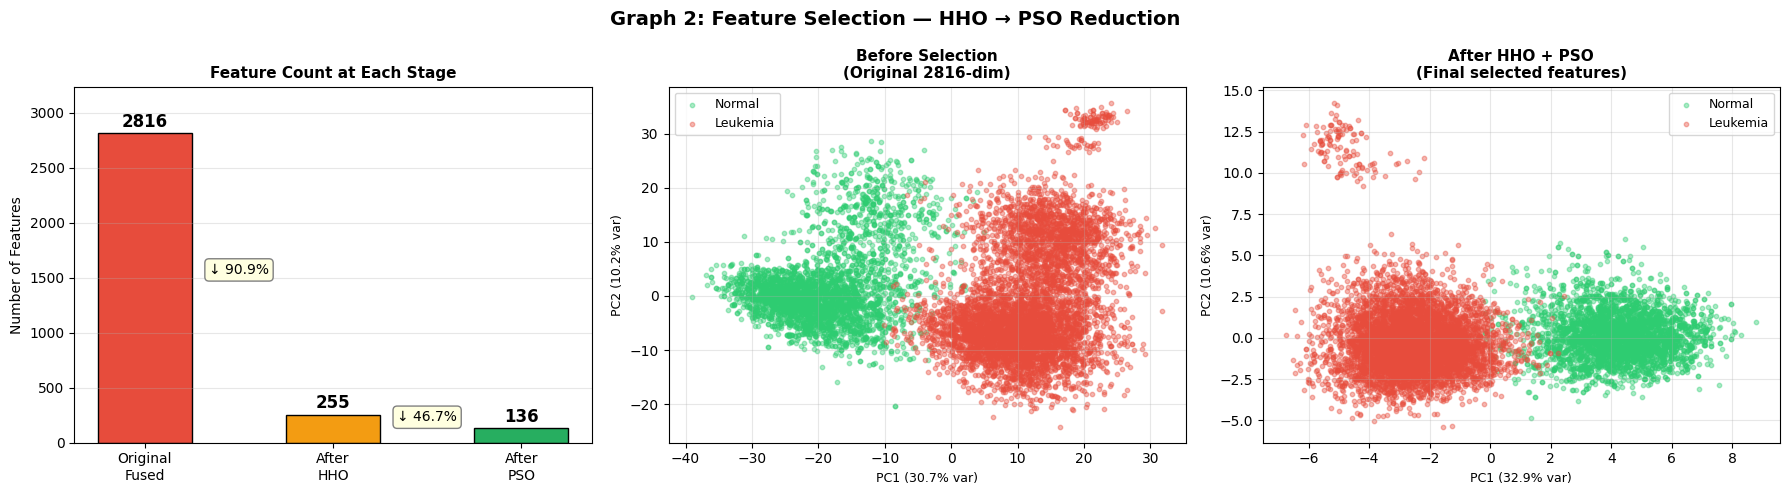

Graph 2 saved ✅


In [39]:
# ── Graph 2: Feature Selection — HHO vs PSO ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Graph 2: Feature Selection — HHO → PSO Reduction",
             fontsize=14, fontweight='bold')

# ── 2a: Feature count reduction bar chart ────────────────────────────────────
stages  = ['Original\nFused', 'After\nHHO', 'After\nPSO']
counts  = [X_train_feat.shape[1],
           X_train_hho.shape[1],
           X_train_final.shape[1]]
colors  = ['#e74c3c', '#f39c12', '#27ae60']

bars = axes[0].bar(stages, counts, color=colors, edgecolor='black', width=0.5)
for bar, c in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20, str(c),
                 ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_ylabel("Number of Features", fontsize=10)
axes[0].set_title("Feature Count at Each Stage", fontsize=11, fontweight='bold')
axes[0].set_ylim(0, max(counts) * 1.15)
axes[0].grid(axis='y', alpha=0.3)

# Add reduction % annotations
reductions = [
    f"↓ {(1 - counts[1]/counts[0])*100:.1f}%",
    f"↓ {(1 - counts[2]/counts[1])*100:.1f}%"
]
for i, txt in enumerate(reductions):
    axes[0].annotate(txt,
                     xy=((i + i+1)/2, (counts[i] + counts[i+1])/2),
                     fontsize=10, color='black',
                     ha='center',
                     bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', ec='gray'))

# ── 2b: PCA of features before HHO vs after PSO ──────────────────────────────
for ax, X, title, color_pos, color_neg in zip(
    [axes[1], axes[2]],
    [X_train_feat, X_train_final],
    ["Before Selection\n(Original 2816-dim)",
     "After HHO + PSO\n(Final selected features)"],
    ['#e74c3c', '#27ae60'],
    ['#3498db', '#9b59b6']
):
    pca  = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X)
    var  = pca.explained_variance_ratio_

    ax.scatter(X_2d[y_train_np==0, 0], X_2d[y_train_np==0, 1],
               c='#2ecc71', alpha=0.4, s=10, label='Normal')
    ax.scatter(X_2d[y_train_np==1, 0], X_2d[y_train_np==1, 1],
               c='#e74c3c', alpha=0.4, s=10, label='Leukemia')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(f"PC1 ({var[0]*100:.1f}% var)", fontsize=9)
    ax.set_ylabel(f"PC2 ({var[1]*100:.1f}% var)", fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("graph2_feature_selection.png", dpi=150, bbox_inches='tight')
plt.show()
print("Graph 2 saved ✅")

In [40]:
xgb_model = xgb.XGBClassifier(
    n_estimators          = 400,
    max_depth             = 7,
    learning_rate         = 0.05,
    subsample             = 0.85,
    colsample_bytree      = 0.85,
    min_child_weight      = 1,
    gamma                 = 0.0,
    reg_alpha             = 0.0,
    reg_lambda            = 1.0,
    scale_pos_weight      = 904/1482,  # ← handles class imbalance (Normal/Leukemia ratio)
    eval_metric           = "auc",     # ← changed from logloss to auc
    early_stopping_rounds = 40,
    use_label_encoder     = False,
    random_state          = 42,
    device                = "cuda" if torch.cuda.is_available() else "cpu"
)

xgb_model.fit(
    X_train_final, y_train_np,
    eval_set = [(X_test_final, y_test_np)],
    verbose  = 50
)

print("\nXGBoost training complete ✅")

[0]	validation_0-auc:0.94484
[50]	validation_0-auc:0.96497
[100]	validation_0-auc:0.96840
[150]	validation_0-auc:0.97104
[200]	validation_0-auc:0.97180
[225]	validation_0-auc:0.97112

XGBoost training complete ✅


✅ Model 3 Accuracy : 94.30%

              precision    recall  f1-score   support

  Normal (0)       0.94      0.91      0.92       904
Leukemia (1)       0.95      0.96      0.95      1482

    accuracy                           0.94      2386
   macro avg       0.94      0.94      0.94      2386
weighted avg       0.94      0.94      0.94      2386

RMSE : 0.2286
MAE  : 0.0597
R²   : 0.7779


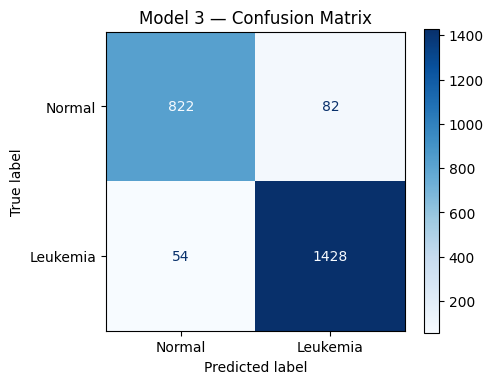

In [41]:
y_pred      = xgb_model.predict(X_test_final)
y_pred_prob = xgb_model.predict_proba(X_test_final)[:, 1]

# ── Classification Metrics ────────────────────────────────────────────────────
acc = accuracy_score(y_test_np, y_pred)
print(f"✅ Model 3 Accuracy : {acc * 100:.2f}%\n")
print(classification_report(y_test_np, y_pred,
                             target_names=["Normal (0)", "Leukemia (1)"]))

# ── Regression Metrics on probabilities ──────────────────────────────────────
rmse = np.sqrt(mean_squared_error(y_test_np, y_pred_prob))
mae  = mean_absolute_error(y_test_np, y_pred_prob)
r2   = r2_score(y_test_np, y_pred_prob)
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test_np, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Leukemia"]).plot(ax=ax, cmap="Blues")
plt.title("Model 3 — Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix_model3.png", dpi=150)
plt.show()

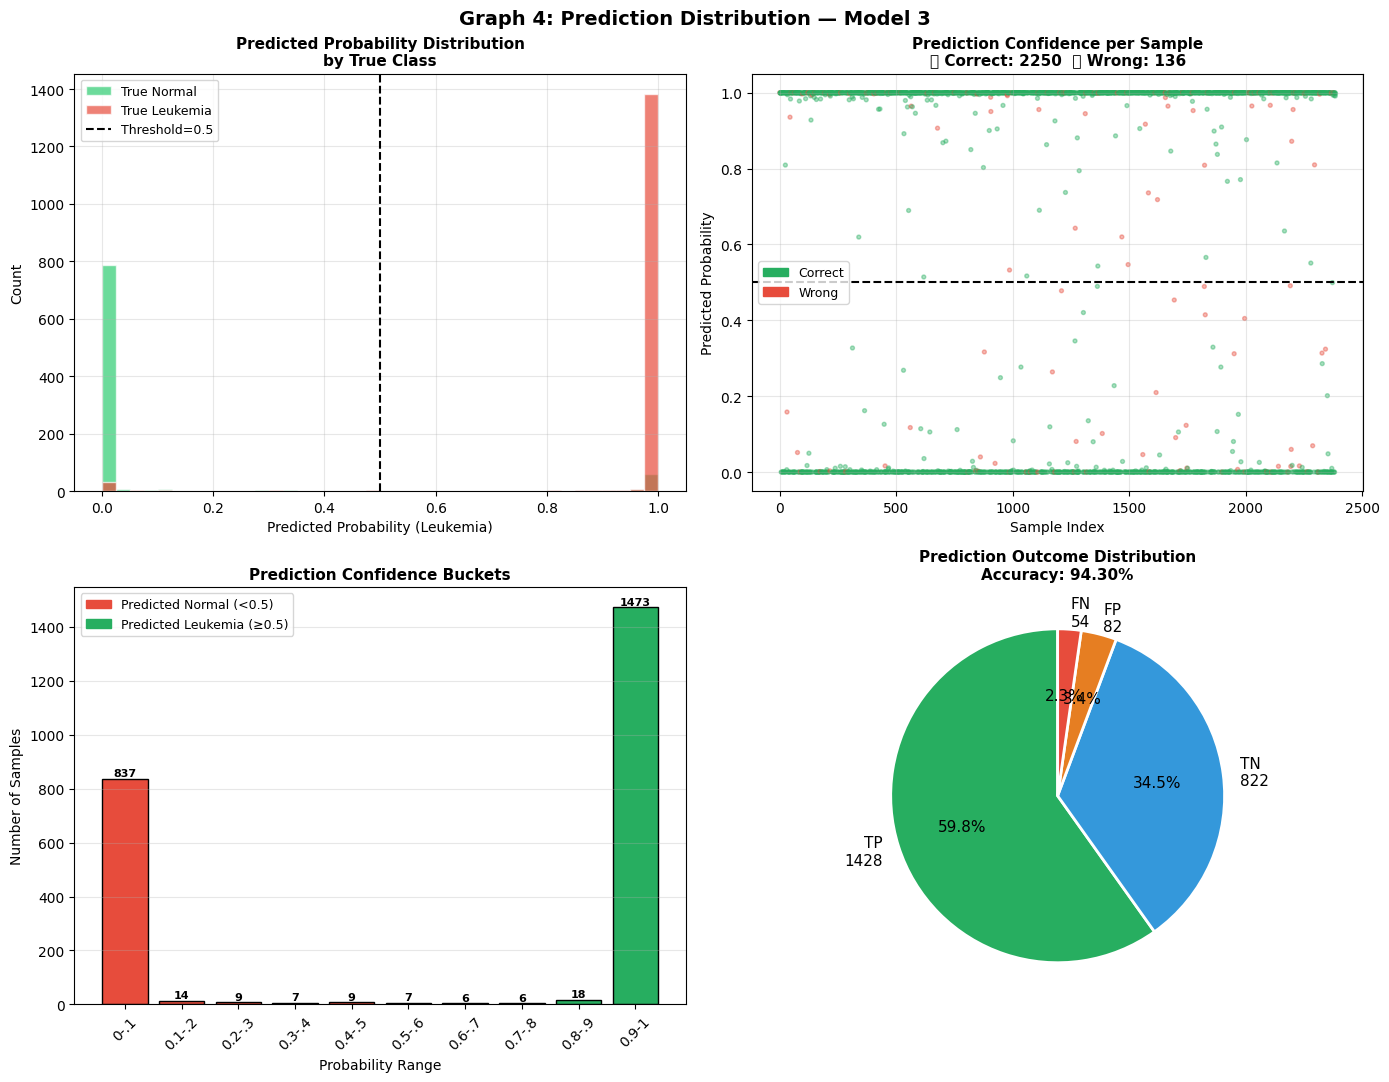

Graph 4 saved ✅


In [42]:
# ── Graph 4: Prediction Distribution ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle("Graph 4: Prediction Distribution — Model 3",
             fontsize=14, fontweight='bold')

# ── 4a: Probability distribution by true class ───────────────────────────────
axes[0,0].hist(y_pred_prob[y_test_np==0], bins=40,
               color='#2ecc71', alpha=0.7, label='True Normal',   edgecolor='white')
axes[0,0].hist(y_pred_prob[y_test_np==1], bins=40,
               color='#e74c3c', alpha=0.7, label='True Leukemia', edgecolor='white')
axes[0,0].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold=0.5')
axes[0,0].set_title("Predicted Probability Distribution\nby True Class",
                    fontsize=11, fontweight='bold')
axes[0,0].set_xlabel("Predicted Probability (Leukemia)", fontsize=10)
axes[0,0].set_ylabel("Count", fontsize=10)
axes[0,0].legend(fontsize=9)
axes[0,0].grid(True, alpha=0.3)

# ── 4b: Correct vs Wrong predictions ─────────────────────────────────────────
correct = (y_pred == y_test_np)
axes[0,1].scatter(range(len(y_pred_prob)),
                  y_pred_prob,
                  c=['#27ae60' if c else '#e74c3c' for c in correct],
                  alpha=0.4, s=8)
axes[0,1].axhline(0.5, color='black', linestyle='--', linewidth=1.5)
axes[0,1].set_title(f"Prediction Confidence per Sample\n"
                    f"✅ Correct: {correct.sum()}  ❌ Wrong: {(~correct).sum()}",
                    fontsize=11, fontweight='bold')
axes[0,1].set_xlabel("Sample Index", fontsize=10)
axes[0,1].set_ylabel("Predicted Probability", fontsize=10)
from matplotlib.patches import Patch
axes[0,1].legend(handles=[Patch(color='#27ae60', label='Correct'),
                           Patch(color='#e74c3c', label='Wrong')], fontsize=9)
axes[0,1].grid(True, alpha=0.3)

# ── 4c: Confidence buckets ────────────────────────────────────────────────────
bins_     = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
labels_   = ['0-.1','0.1-.2','0.2-.3','0.3-.4','0.4-.5',
             '0.5-.6','0.6-.7','0.7-.8','0.8-.9','0.9-1']
counts_   = np.histogram(y_pred_prob, bins=bins_)[0]
bar_cols  = ['#e74c3c' if i < 5 else '#27ae60' for i in range(10)]

axes[0,2 if len(axes[0])>2 else 0]  # skip — only 2 cols
b = axes[1,0].bar(labels_, counts_, color=bar_cols, edgecolor='black', width=0.8)
for bar, cnt in zip(b, counts_):
    if cnt > 0:
        axes[1,0].text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + 1, str(cnt),
                       ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[1,0].set_title("Prediction Confidence Buckets", fontsize=11, fontweight='bold')
axes[1,0].set_xlabel("Probability Range", fontsize=10)
axes[1,0].set_ylabel("Number of Samples", fontsize=10)
axes[1,0].tick_params(axis='x', rotation=45)
from matplotlib.patches import Patch
axes[1,0].legend(handles=[Patch(color='#e74c3c', label='Predicted Normal (<0.5)'),
                           Patch(color='#27ae60', label='Predicted Leukemia (≥0.5)')],
                 fontsize=9)
axes[1,0].grid(axis='y', alpha=0.3)

# ── 4d: Pie chart of outcomes ─────────────────────────────────────────────────
TP = ((y_pred==1) & (y_test_np==1)).sum()
TN = ((y_pred==0) & (y_test_np==0)).sum()
FP = ((y_pred==1) & (y_test_np==0)).sum()
FN = ((y_pred==0) & (y_test_np==1)).sum()

axes[1,1].pie([TP, TN, FP, FN],
              labels=[f'TP\n{TP}', f'TN\n{TN}', f'FP\n{FP}', f'FN\n{FN}'],
              colors=['#27ae60', '#3498db', '#e67e22', '#e74c3c'],
              autopct='%1.1f%%', startangle=90,
              textprops={'fontsize': 11},
              wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1,1].set_title(f"Prediction Outcome Distribution\nAccuracy: {acc*100:.2f}%",
                    fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("graph4_prediction_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Graph 4 saved ✅")

⏳ Computing SHAP values (this may take 1–2 min)...


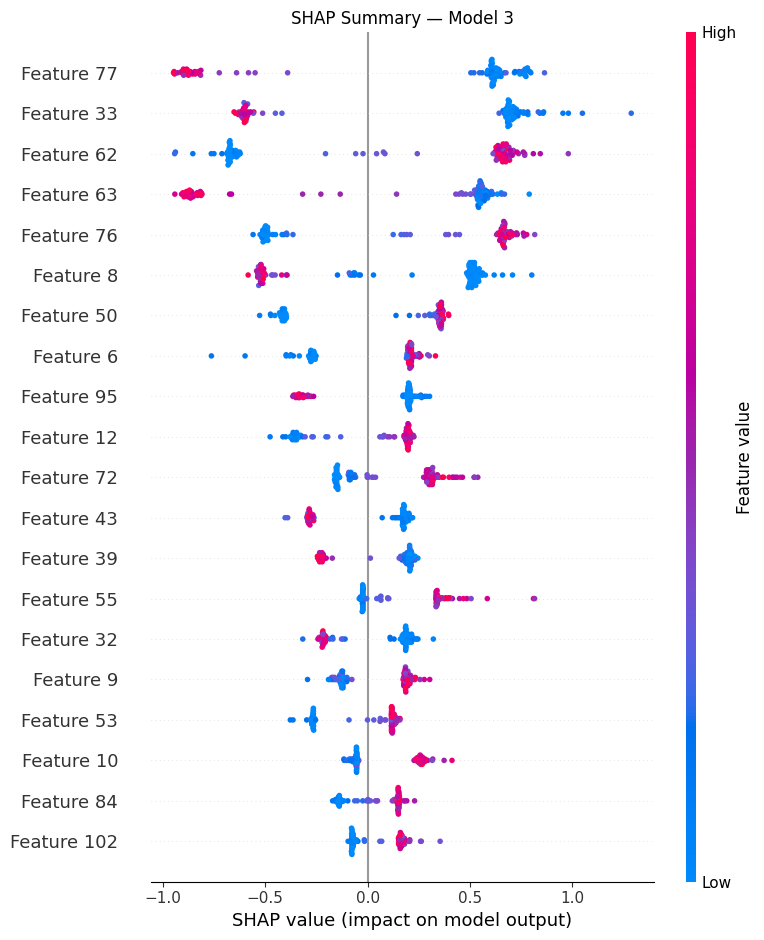

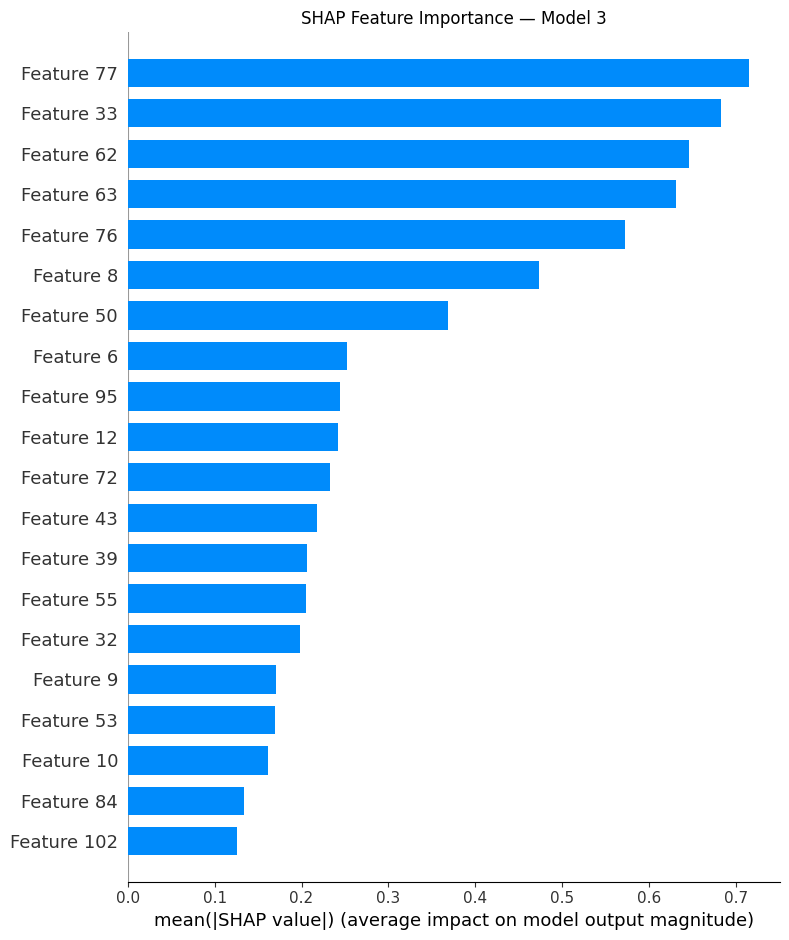

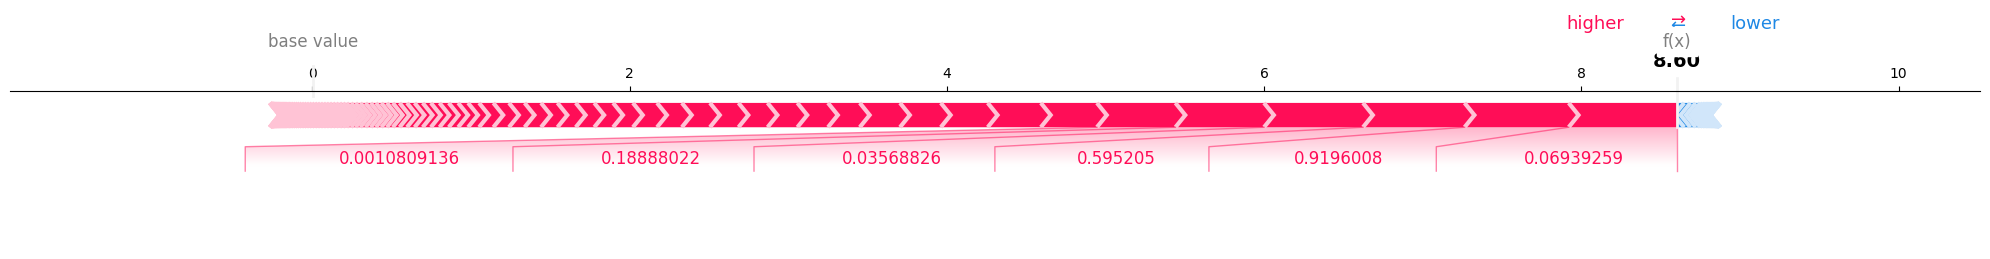

SHAP plots saved ✅


In [43]:
print("⏳ Computing SHAP values (this may take 1–2 min)...")

explainer   = shap.TreeExplainer(xgb_model)
shap_sample = X_test_final[:100]           # use 100 test samples
shap_values = explainer.shap_values(shap_sample)

# ── Summary Plot ──────────────────────────────────────────────────────────────
plt.figure()
shap.summary_plot(shap_values, shap_sample, show=False)
plt.title("SHAP Summary — Model 3")
plt.tight_layout()
plt.savefig("shap_summary_model3.png", dpi=150)
plt.show()

# ── Bar Plot (global importance) ──────────────────────────────────────────────
plt.figure()
shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False)
plt.title("SHAP Feature Importance — Model 3")
plt.tight_layout()
plt.savefig("shap_bar_model3.png", dpi=150)
plt.show()

# ── Force Plot for 1 prediction ───────────────────────────────────────────────
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    shap_sample[0],
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.savefig("shap_force_model3.png", dpi=150)
plt.show()
print("SHAP plots saved ✅")

In [44]:
import joblib
import numpy as np
import os

# ── Save model and feature indices ───────────────────────────────────────────
joblib.dump(xgb_model, "/kaggle/working/model3_xgboost.pkl")
np.save("/kaggle/working/hho_selected_indices.npy", hho_idx)
np.save("/kaggle/working/pso_selected_indices.npy", pso_idx)

# ── Save predictions (needed for ensemble) ───────────────────────────────────
y_pred_m3       = xgb_model.predict(X_test_final)
y_pred_proba_m3 = xgb_model.predict_proba(X_test_final)  # shape: (N, 2)
y_true_m3       = y_test_np

np.save("/kaggle/working/model3_y_pred.npy",       y_pred_m3)
np.save("/kaggle/working/model3_y_pred_proba.npy", y_pred_proba_m3)
np.save("/kaggle/working/model3_y_true.npy",       y_true_m3)

# ── Verify everything ─────────────────────────────────────────────────────────
print("✅ All files saved to /kaggle/working/")
print(f"   y_pred       : {y_pred_m3.shape}       | unique: {np.unique(y_pred_m3)}")
print(f"   y_pred_proba : {y_pred_proba_m3.shape}  | sample: {y_pred_proba_m3[0]}")
print(f"   y_true       : {y_true_m3.shape}       | unique: {np.unique(y_true_m3)}")
print()
print("Files in /kaggle/working/:")
for f in sorted(os.listdir("/kaggle/working/")):
    size = os.path.getsize(f"/kaggle/working/{f}")
    print(f"   {f}  →  {size/1024:.1f} KB")


✅ All files saved to /kaggle/working/
   y_pred       : (2386,)       | unique: [0 1]
   y_pred_proba : (2386, 2)  | sample: [1.8316507e-04 9.9981683e-01]
   y_true       : (2386,)       | unique: [0 1]

Files in /kaggle/working/:
   .virtual_documents  →  4.0 KB
   best_ft_resnet.pth  →  96243.7 KB
   common_test_set.csv  →  276.2 KB
   confusion_matrix_model3.png  →  35.2 KB
   graph1_feature_extraction.png  →  578.3 KB
   graph2_feature_selection.png  →  516.5 KB
   graph3_convergence.png  →  99.8 KB
   graph4_prediction_distribution.png  →  271.5 KB
   hho_selected_indices.npy  →  2.1 KB
   model3_xgboost.pkl  →  273.7 KB
   model3_y_pred.npy  →  18.8 KB
   model3_y_pred_proba.npy  →  18.8 KB
   model3_y_true.npy  →  18.8 KB
   pso_selected_indices.npy  →  1.2 KB
   report.log  →  16.0 KB
   shap_bar_model3.png  →  94.7 KB
   shap_force_model3.png  →  65.6 KB
   shap_summary_model3.png  →  184.9 KB


In [45]:
import joblib

joblib.dump(xgb_model,  "model3_xgboost.pkl")
np.save("hho_selected_indices.npy", hho_idx)
np.save("pso_selected_indices.npy", pso_idx)
np.save("X_train_final.npy", X_train_final)
np.save("X_test_final.npy",  X_test_final)
np.save("y_test.npy",        y_test_np)

print("All files saved ✅")
print(os.listdir("."))

# If ALL_IDB uses im/ folder with filename labels:
ALL_IDB_DIR = "/kaggle/input/all-leukemia-dataset/ALL_IDB/im"
# Files ending in _1.jpg = malignant, _0.jpg = benign

# If C-NMC uses fold0/fold1 structure:
CNMC_BENIGN = "/kaggle/input/all-leukemia-dataset/C-NMC_Leukemia/training_data/fold0/hem"

All files saved ✅
['confusion_matrix_model3.png', 'y_test.npy', 'shap_force_model3.png', 'graph4_prediction_distribution.png', 'graph3_convergence.png', 'X_train_final.npy', 'pso_selected_indices.npy', 'model3_xgboost.pkl', 'best_ft_resnet.pth', 'hho_selected_indices.npy', 'shap_summary_model3.png', 'model3_y_true.npy', 'model3_y_pred.npy', 'shap_bar_model3.png', 'model3_y_pred_proba.npy', 'common_test_set.csv', 'report.log', 'X_test_final.npy', 'graph2_feature_selection.png', '.virtual_documents', 'graph1_feature_extraction.png']
